In [716]:
import requests
import os
import pandas as pd
from tqdm import tqdm
from datetime import date
from bs4 import BeautifulSoup, Comment
from copy import deepcopy
from random import randint

In [371]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import SMOTE

In [65]:
def clean_columns(df):
    df.columns = df.columns.get_level_values(1)
    dupIndex = list(df.columns).index('W-L%',list(df.columns).index('W-L%')+1)
    df.columns.values[dupIndex] = 'W-L% plyf'
    return df

In [10]:
# TODO: account for active coach or not
def get_coach(coach,fetch=False):
    url = f'https://www.pro-football-reference.com/coaches/{coach}.htm'
    file_name = f"input/coaches/tables/{url.split('/')[-1].split('.')[0]}.csv"

    if os.path.exists(file_name):
        return pd.read_csv(file_name,index_col=0)

    else :
        ret = requests.get(url).text
        ret = pd.read_html(ret)[0]
        ret = clean_columns(ret)
        ret.to_csv(file_name)
        return ret

In [707]:
# TODO: reading in every coach from 2023
COACHES = pd.read_csv('input/coaches23.csv')
for c in tqdm(coaches['name'].values):
    get_coach(c)

100%|██████████| 524/524 [00:00<00:00, 1360.67it/s]


In [739]:
def rand_coach(pool=COACHES):
    coach = COACHES.values[randint(0,len(COACHES))][0]
    print(coach)
    return coach

In [708]:
get_coach(COACHES.iloc[0][0]).head()

,Year,Age,Tm,Lg,G,W,L,T,W-L%,SRS,OSRS,DSRS,G plyf,W plyf,L plyf,W-L% plyf,Rank,Notes
0,1963,33,BAL,NFL,14,8,6,0,0.571,2.0,0.8,1.2,NaN,NaN,NaN,NaN,3.0,NaN
1,1964,34,BAL,NFL,14,12,2,0,0.857,15.5,9.3,6.2,1.0,0.0,1.0,0.0,1.0,NaN
2,1965,35,BAL,NFL,14,10,3,1,0.769,12.9,7.0,5.9,1.0,0.0,1.0,0.0,1.0,NaN
3,1966,36,BAL,NFL,14,9,5,0,0.643,7.6,2.2,5.5,NaN,NaN,NaN,NaN,2.0,NaN
4,1967,37,BAL,NFL,14,11,1,2,0.917,13.2,6.4,6.8,NaN,NaN,NaN,NaN,1.0,NaN


### TODO
1. convert and save processed tables -> cut bottom rows from tables and label, likely trim Lg, G, W, L, T, Rank, W plyf, DSRS
--> toy with whether certain columns matter -> make this dynamic
2. run quick and dirty model on just that season, w/o any knowledge of other seasons --> call it "online"
3. add exp columns to rows, then see if model outperforms

In [9]:
def fixCol(df,col,typ):
    df[col] = df[col].fillna(0).astype(typ)
    return df

In [335]:
def clean_rows(coach,footerBool=False):
    df = get_coach(coach)
    footer = df[~(df['Year'].str.isdigit())]
    rows = df[df['Year'].str.isdigit()].copy()

    if 'Num' not in df.columns :
        rows.insert(len(df.columns)-1,'Num',0)
        rows.insert(len(df.columns)-1,'Won',0)
    
    rows = rows.fillna(0)
    
    for col in ['Age','Year']:
        rows[col] = rows[col].astype(int)
    
    rows['Notes'] = rows['Notes'].astype(str)

    return rows if not footerBool else footer

In [198]:
retired = [
    'CowhBi-06',
    'DungTo-08',
    'MaddJo0-78',
    'NollCh0-91',
    'LevyMa0-97',
    'LandTo0-88',
    'VermDi0-05',
    'ShulDo0-95',
    'LombVi0-67',
    'LombVi0-69',
    'HalaGe0-67',
    'ParcBi0-90',
    'ParcBi0-96',
    'ParcBi0-99',
    'ParcBi0-06',
    'AriaBr0-17',
    'AriaBr0-21',
    'KubiGa0-16',
    'GranBu0-83',
    'BrowPa0-75',
    'SchoMa0-98',
    'CougTo0-15'
]

In [199]:
fired = {
    'CarrPe0-23',
    'BellBe0-23',
    'StalBr0-23',
    'RiveRo0-23',
    'SmitAr0-23',
    'ReicFr0-23',
    'VrabMi0-23',
    'McDaJo0-23'
}

In [214]:
def check_fired(year,coach,retired=retired):
    label = f'{coach}-{str(year)[2:]}'
    if label in retired:
        return 0
    elif str(year)=='2023' and label in fired:
        return 1
    elif str(year)=='2023':
        return 0
    else:
        return 1

In [622]:
def label_fired(coach,since=1966,full=False):
    df = clean_rows(coach)
    df['Fired'] = 0
    last_years = df.groupby('Tm')['Year'].idxmax()
    for idx in last_years:
        df.loc[idx, 'Fired'] = check_fired(df.loc[idx,'Year'],coach)
    if full : return df
    return df[df['Year'] >= since]

### Quick and Dirty Online Model

Fix ConzJi0's double 1922 head coaching year and GibsGe0's double 1930 head coaching year

In [216]:
shula = coaches.iloc[0][0]
coach2 = coaches.iloc[0][0]
label_fired(shula).tail()

,Year,Age,Tm,Lg,G,W,L,T,W-L%,SRS,...,DSRS,G plyf,W plyf,L plyf,W-L% plyf,Rank,Won,Num,Notes,Fired
28,1991,61,MIA,NFL,16,8,8,0,0.500,-4.1,...,-4.8,0.0,0.0,0.0,0.0,3.0,0,0,0,0
29,1992,62,MIA,NFL,16,11,5,0,0.688,1.5,...,-0.6,2.0,1.0,1.0,0.5,1.0,0,0,0,0
30,1993,63,MIA,NFL,16,9,7,0,0.563,-0.5,...,-4.3,0.0,0.0,0.0,0.0,2.0,0,0,0,0
31,1994,64,MIA,NFL,16,10,6,0,0.625,4.2,...,-0.3,2.0,1.0,1.0,0.5,1.0,0,0,0,0
32,1995,65,MIA,NFL,16,9,7,0,0.563,2.7,...,-0.4,1.0,0.0,1.0,0.0,3.0,0,0,0,0


In [282]:
def quick_dirty(coach,since=1966):
    df = label_fired(coach)
    filtered = df[df['Year'] >= since]
    return filtered[['W-L%','SRS','W-L% plyf','Fired']]

In [563]:
# TODO, since should not have no to be passed to the method, it should be handled elsewhere as with filtering out interim coaches
def aggregate(method,since=1966):
    coaches = pd.read_csv('input/coaches23.csv')['name'].values
    dfs = [method(coach=coach,since=since) for coach in coaches]
    agg = pd.concat(dfs).reset_index(drop=True)
    return agg

In [238]:
aggregate(quick_dirty)

,W-L%,SRS,W-L% plyf,Fired
0,0.571,2.0,0.0,0
1,0.857,15.5,0.0,0
2,0.769,12.9,0.0,0
3,0.643,7.6,0.0,0
4,0.917,13.2,0.0,0
...,...,...,...,...
2521,0.000,-21.2,0.0,1
2522,0.000,-7.3,0.0,1
2523,0.000,-38.5,0.0,1
2524,0.000,-20.1,0.0,1


#### Model

In [374]:
def log_regression(method=quick_dirty,smote=False):
    data = aggregate(method)
    X = data.drop(columns=['Fired'])
    y = data['Fired']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if smote:
        smote = SMOTE(sampling_strategy='minority')
        X_train, y_train = smote.fit_resample(X_train,y_train)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
    print(classification_report(y_test, y_pred))

    RocCurveDisplay.from_estimator(model, X_test, y_test)

Accuracy: 0.7154696132596685
              precision    recall  f1-score   support

           0       0.92      0.69      0.79       278
           1       0.44      0.81      0.57        84

    accuracy                           0.72       362
   macro avg       0.68      0.75      0.68       362
weighted avg       0.81      0.72      0.74       362



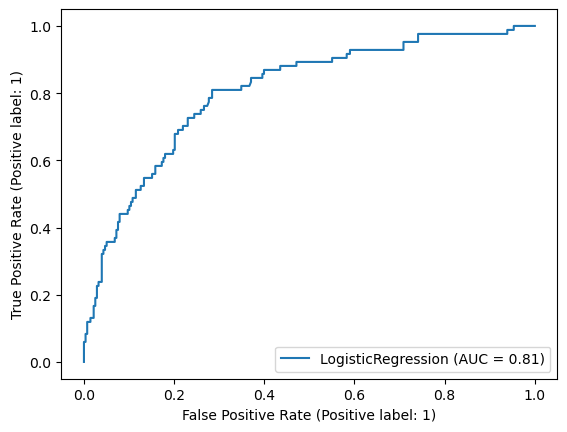

In [376]:
log_regression(quick_dirty,smote=True)

### Looking at Experience

- Find a good and elegant way to look at tenure W, tenure L --> maybe that is a single column
- tenure w-l% plyf
- slope metric that measures playoff performance (maybe create input that looks at team performance each year)

In [300]:
PLAYOFF_STANDINGS = pd.read_csv('input/playoff_standings.csv')

In [ ]:
def quick_dirty(coach,since=1966):
    df = label_fired(coach)
    filtered = df[df['Year'] >= since]
    return filtered[['W-L%','SRS','W-L% plyf','Fired']]

#### Playoff Round Reached
should be done to aggregated data in post-processing

In [625]:
def with_playoffs(coach,full=False,results=PLAYOFF_STANDINGS):
    df = label_fired(coach,full)
    results = results[['Tm','Year','Round']]
    df = pd.merge(df,results,how='left',left_on=['Tm','Year'],right_on=['Tm','Year'])
    df['Round'] = df['Round'].fillna(0).astype(int)
    return df

#### Adding Tenure

In [629]:
# pre 1966 will be filtered out 
def filter_interim(df):
    df = df[~df['Notes'].str.contains('starting|interim', case=False, na=False)] # if interim labeled
    df = df[~((df['G'] < 14) & (~df['Notes'].str.contains('fired', case=False, na=False)))] # approximate check if interim not labeled
    return df

In [630]:
def with_tenure(coach,since=1966,full=False):
    df = with_playoffs(coach,full)
    df = df.reset_index(names=['Exp'])
    df['Tenure'] = df.groupby('Tm',group_keys=False)['Year'].apply(lambda x: (x.diff() == 1).cumsum()+1)
    df['(W-L)'] = df['W'] - df['L']
    df['Tenure (W-L)'] = df.groupby('Tm')['W'].cumsum() - df.groupby('Tm')['L'].cumsum()
    df['Tenure W plyf'] = df.groupby('Tm')['W plyf'].cumsum()
    df = filter_interim(df)
    if full: return df
    filtered = df[df['Year'] >= since]
    return filtered[['Round','W plyf','(W-L)','Exp','Tenure','Tenure (W-L)','Tenure W plyf','SRS','Fired']]

SMOTE oversampling: True
Accuracy: 0.676923076923077
              precision    recall  f1-score   support

           0       0.95      0.65      0.78       278
           1       0.28      0.81      0.42        47

    accuracy                           0.68       325
   macro avg       0.62      0.73      0.60       325
weighted avg       0.86      0.68      0.72       325

SMOTE oversampling: False
Accuracy: 0.8369230769230769
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       278
           1       0.36      0.17      0.23        47

    accuracy                           0.84       325
   macro avg       0.62      0.56      0.57       325
weighted avg       0.80      0.84      0.81       325



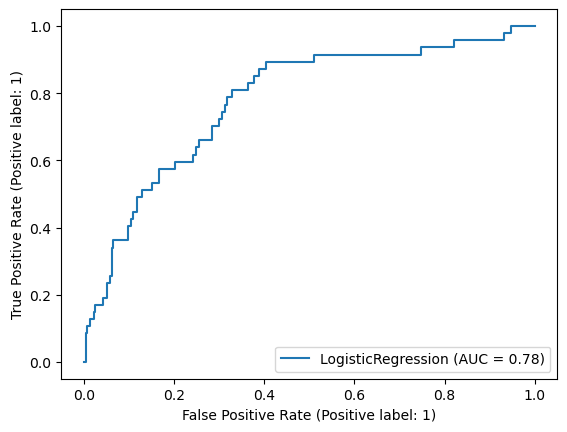

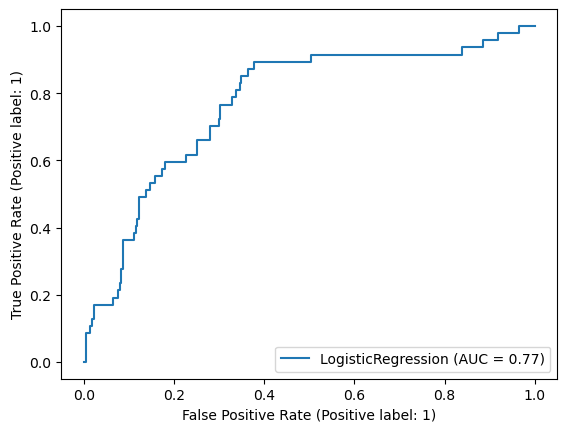

In [624]:
for boolean in [True,False]:
    print(f'SMOTE oversampling: {boolean}')
    log_regression(with_tenure,smote=boolean)

- 84% accuracy is not all that good on the whole, but it is more concerning that we are struggling even more than the quick and dirty model on guessing firings.
- It is also disappointing that SMOTE minority oversampling isn't helping our model all that much

### Did the GM hire you?
This is probably one of the more data intensive questions to answer, but it is likely a key piece to our model.
- TODO: Was it the same owner?

#### Scraping the data locally

In [601]:
abbrevs_path = 'input/nfl_team_abbrevs.csv'
gm = pd.read_csv(abbrevs_path,index_col=0)

In [602]:
def get_gm(abbrev,year=2023):
    path = f'input/teams/{abbrev}{year}.htm'
    if not os.path.exists(path): return 'null'
    text = ''
    with open(path, 'r') as f:
        text = f.read()
    names = [tag.a.text for tag in BeautifulSoup(text).find_all('p') if 'General Manager' in tag.text]
    if len(names) > 0 : return names[0]
    return ''

In [603]:
for year in range(1921,2024):
    gm[year] = gm['Abbrev'].apply(lambda abbrev: get_gm(abbrev,year))

/var/folders/l4/pc6_sp9x6dv3bjdsjjpz173r0000gn/T/ipykernel_19416/1164928438.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gm[year] = gm['Abbrev'].apply(lambda abbrev: get_gm(abbrev,year))
/var/folders/l4/pc6_sp9x6dv3bjdsjjpz173r0000gn/T/ipykernel_19416/1164928438.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gm[year] = gm['Abbrev'].apply(lambda abbrev: get_gm(abbrev,year))
/var/folders/l4/pc6_sp9x6dv3bjdsjjpz173r0000gn/T/ipykernel_19416/1164928438.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usu

In [604]:
gm.set_index('Abbrev').to_csv('processed/gm.csv')

#### Implementing the code

In [685]:
# small bugs like Baltimore Colts and Baltimore Ravens
ALT_ABBREV_DICT = {
    'HOU' : 'HTX',
    'TEN' : 'OTI',
    'ARI' : 'CRD',
    'BAL' : 'RAV',
    'LAC' : 'SDG',
    'LVR' : 'RAI',
    'LAR' : 'RAM',
    'STL' : 'RAM',
    'IND' : 'CLT',
    'DTX' : 'KAN',
    'OAK' : 'RAI',
    'BOS' : 'NWE'
}
ABBREVS = pd.read_csv(abbrevs_path,index_col=0)['Abbrev'].values
GM_DICT = pd.read_csv('processed/gm.csv',index_col=0)

In [686]:
def convert_team(abbrev,abbrevs=ABBREVS,dictionary=ALT_ABBREV_DICT):
    if abbrev not in dictionary and abbrev in ABBREVS: return abbrev
    elif abbrev in dictionary: return dictionary[abbrev]
    return 'N/A'

In [700]:
def compare_gm(df,team,year,year_one):
    team = convert_team(team)
    if team == 'N/A': return 0
    curr = df[str(year)].loc[team]
    y1 = df[str(year_one)].loc[team]
    if curr == y1 and not pd.isna(y1) : return 1
    if pd.isna(curr) and pd.isna(y1) : return 0
    return -1

In [701]:
def with_gm(coach,since=1966,full=False):
    df = with_tenure(coach,full=True)
    df['Y1'] = df.groupby(['Tm'])['Year'].transform('min')
    df['gm'] = df.apply(lambda row: compare_gm(GM_DICT,row['Tm'],row['Year'],row['Y1']),axis=1)
    df.drop(columns=['Y1'])
    if full: return df
    filtered = df[df['Year'] >= since]
    return filtered[['Round','W plyf','(W-L)','Exp','Tenure','Tenure (W-L)','Tenure W plyf','SRS','Fired','gm']]

In [762]:
with_gm(rand_coach(),full=True)

VrabMi0


,Exp,Year,Age,Tm,Lg,G,W,L,T,W-L%,...,Won,Notes,Fired,Round,Tenure,(W-L),Tenure (W-L),Tenure W plyf,Y1,gm
0,0,2018,43,TEN,NFL,16,9,7,0,0.563,...,0,0.0,0,0,1,2,2,0.0,2018,1
1,1,2019,44,TEN,NFL,16,9,7,0,0.563,...,3,0.0,0,0,2,2,4,2.0,2018,1
2,2,2020,45,TEN,NFL,16,11,5,0,0.688,...,2,0.0,0,0,3,6,10,2.0,2018,1
3,3,2021,46,TEN,NFL,17,12,5,0,0.706,...,4,0.0,0,0,4,7,17,2.0,2018,1
4,4,2022,47,TEN,NFL,17,7,10,0,0.412,...,2,0.0,0,0,5,-3,14,2.0,2018,-1
5,5,2023,48,TEN,NFL,17,6,11,0,0.353,...,3,0.0,1,0,6,-5,9,2.0,2018,-1


Accuracy: 0.8461538461538461
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       278
           1       0.44      0.23      0.31        47

    accuracy                           0.85       325
   macro avg       0.66      0.59      0.61       325
weighted avg       0.82      0.85      0.83       325



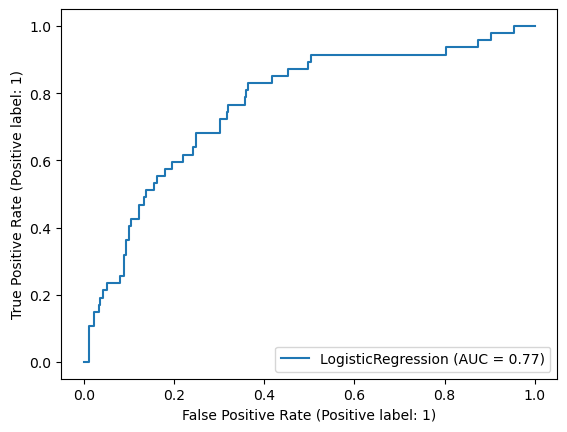

In [706]:
log_regression(with_gm,smote=False)

### Derivative Performance
What was the trend of the team relative to previous years?
- both in regular season wins
- and playoffs

### Further Questions to Explore
- is record at home more important than record overall?
- what about record in second half?
- record in one score games?
- race of coach?
- have them won a superbowl with this franchise?
- what was the tenure of the coach before them?
- was it the same QB they came in with? or better: how many different QBs were opening day starters?